In [60]:
import pandas as pd
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Load the data
data = pd.read_csv('new_dataset.csv')

# Count the number of rows in the data frame
num_rows = len(data)

# Display this count
print("Number of rows in the dataset: {}".format(num_rows))

# Information about the data frame
data.info()

# Display the first few rows of the data frame, sorted by the crash date in ascending order
data.sort_values(by='CRASH DATE').head().set_index('CRASH DATE')

Number of rows in the dataset: 2124643
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2124643 entries, 0 to 2124642
Data columns (total 10 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   CRASH DATE                     object 
 1   CRASH TIME                     object 
 2   NUMBER OF PERSONS INJURED      float64
 3   NUMBER OF PERSONS KILLED       float64
 4   NUMBER OF PEDESTRIANS INJURED  int64  
 5   NUMBER OF PEDESTRIANS KILLED   int64  
 6   NUMBER OF CYCLIST INJURED      int64  
 7   NUMBER OF CYCLIST KILLED       int64  
 8   NUMBER OF MOTORIST INJURED     int64  
 9   NUMBER OF MOTORIST KILLED      int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 162.1+ MB


,CRASH TIME,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED
CRASH DATE,,,,,,,,,
01/01/2013,22:07,0.0,0.0,0,0,0,0,0,0
01/01/2013,9:00,2.0,0.0,0,0,0,0,2,0
01/01/2013,17:50,1.0,0.0,0,0,0,0,1,0
01/01/2013,4:00,0.0,0.0,0,0,0,0,0,0
01/01/2013,5:20,1.0,0.0,0,0,0,0,1,0


In [61]:
# Convert 'CRASH DATE' and 'CRASH TIME' columns to datetime
data['CRASH DATE'] = pd.to_datetime(data['CRASH DATE'], errors='coerce')
data['CRASH TIME'] = pd.to_datetime(data['CRASH TIME'], format='%H:%M', errors='coerce').dt.time

# Define time intervals based on daily activities
time_intervals = {
    'Early Morning': (0, 5),
    'Morning': (5, 9),
    'School Hours': (7, 16),
    'Office Hours': (9, 17),
    'Afternoon': (15, 19),
    'Evening': (19, 24)
}

# Categorize each crash time into the defined intervals
def categorize_time(hour):
    for interval, (start, end) in time_intervals.items():
        if start <= hour < end:
            return interval
    return None

# Extract hour from CRASH TIME and apply categorization
data['Time Interval'] = data['CRASH TIME'].apply(lambda x: categorize_time(x.hour) if x else None)

# Group by 'Time Interval' and calculate total injuries and fatalities
time_interval_stats = data.groupby('Time Interval')[['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED']].sum()

# Rename columns for clarity
time_interval_stats.columns = ['Injured', 'Killed']

# Convert Injured and Killed columns to integers
time_interval_stats = time_interval_stats.astype(int)

# Display the statistics as a data frame
time_interval_stats.sort_values(by='Injured', ascending=False)


,Injured,Killed
Time Interval,,
School Hours,229565,769
Evening,155486,825
Afternoon,90236,340
Morning,80284,450
Early Morning,72041,741
Office Hours,45134,123


Note that
1. School Hours shows the most counts of injuries.
   - Children are more likely to get injured on the road during school hours, on their way to school.
   - Maturity and experience are important factors to prevent injuries.
2. Next is Evening Hours.
   - Children are more likely to get injured on the road during evening hours, on their way home from school.
   - It is important to pay attention to children's safety during evening hours.
3. The number of injuries just before Evening Hours is also high.
   - This is when the sunlight starts getting weaker and the visibility is getting worse.
   - It is important to pay attention to children's safety during this time as well.
4. The number of injuries during the day is relatively low, especially during office hours, when compared to other times.
   - This is because there are fewer children on the road during this time.
   - It is important to pay attention to children's safety during school hours and evening hours.

In [62]:
time_interval_stats.sort_values(by='Killed', ascending=False)

,Injured,Killed
Time Interval,,
Evening,155486,825
School Hours,229565,769
Early Morning,72041,741
Morning,80284,450
Afternoon,90236,340
Office Hours,45134,123


Note that
1. The number of deaths is the highest during Evening Hours.
   - People are more likely to die on the road during evening hours, on their way home from work, school, or other activities.
2. The number of deaths is the second highest during School Hours.
    - People are more likely to die on the road during school hours, on their way to school.
3. The least number of deaths occur during office hours.
    - People are less likely to die on the road during office hours, due to their education and experience.

It is important to pay attention to safety during school hours and evening hours.

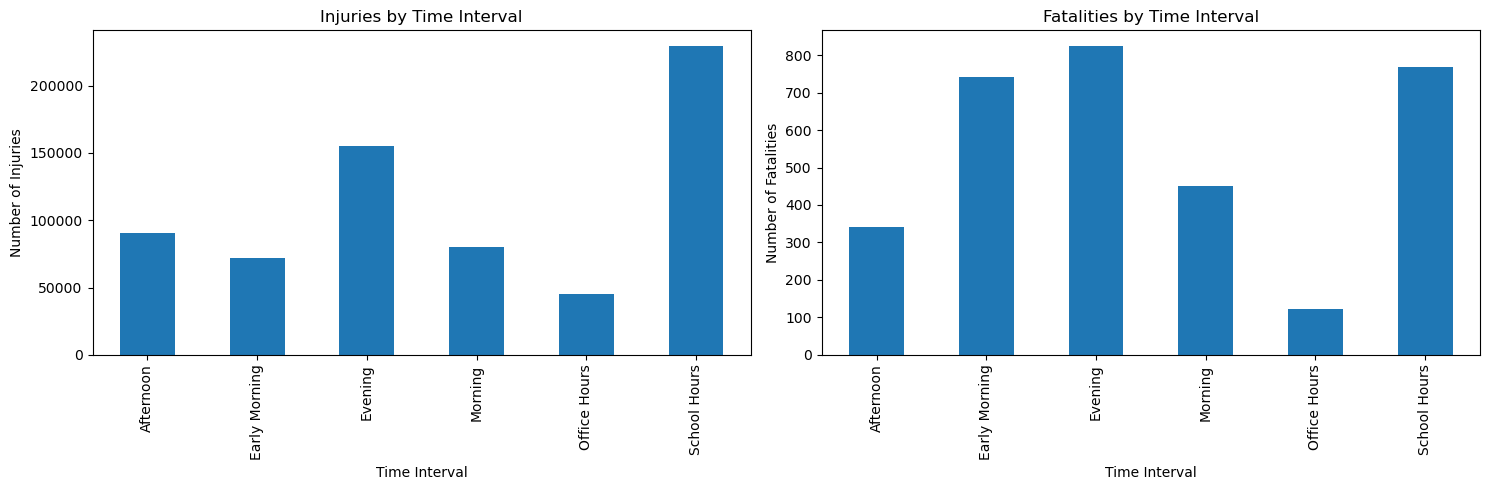

In [63]:
import matplotlib.pyplot as plt

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Draw a bar plot for Injured
time_interval_stats['Injured'].plot(kind='bar', ax=axes[0], stacked=True)
axes[0].set_title('Injuries by Time Interval')
axes[0].set_xlabel('Time Interval')
axes[0].set_ylabel('Number of Injuries')

# Draw a bar plot for Killed
time_interval_stats['Killed'].plot(kind='bar', ax=axes[1], stacked=True)
axes[1].set_title('Fatalities by Time Interval')
axes[1].set_xlabel('Time Interval')
axes[1].set_ylabel('Number of Fatalities')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

In [64]:
# Find the number of injured people in the data frame by year as an integer
injured = data.groupby('CRASH DATE')['NUMBER OF PERSONS INJURED'].sum()

# Find the number of killed people in the data frame by year as an integer
killed = data.groupby('CRASH DATE')['NUMBER OF PERSONS KILLED'].sum()

# Display the number of injured and killed people by year in the data frame
df = pd.DataFrame({'Injured': injured.astype(int), 'Killed': killed.astype(int)})

# The first column should be replaced with the year of the crash date
df.index = pd.to_datetime(df.index).year

# Name the index column as 'Year'
df.index.name = 'Year'

# # If there are duplicate years, the values should be summed
df = df.groupby(df.index).sum()

# Display the first few rows of the updated data frame
df

,Injured,Killed
Year,,
2012,27453,137
2013,55128,297
2014,51226,262
2015,51358,243
2016,60317,246
2017,60656,256
2018,61941,231
2019,61390,244
2020,44614,269


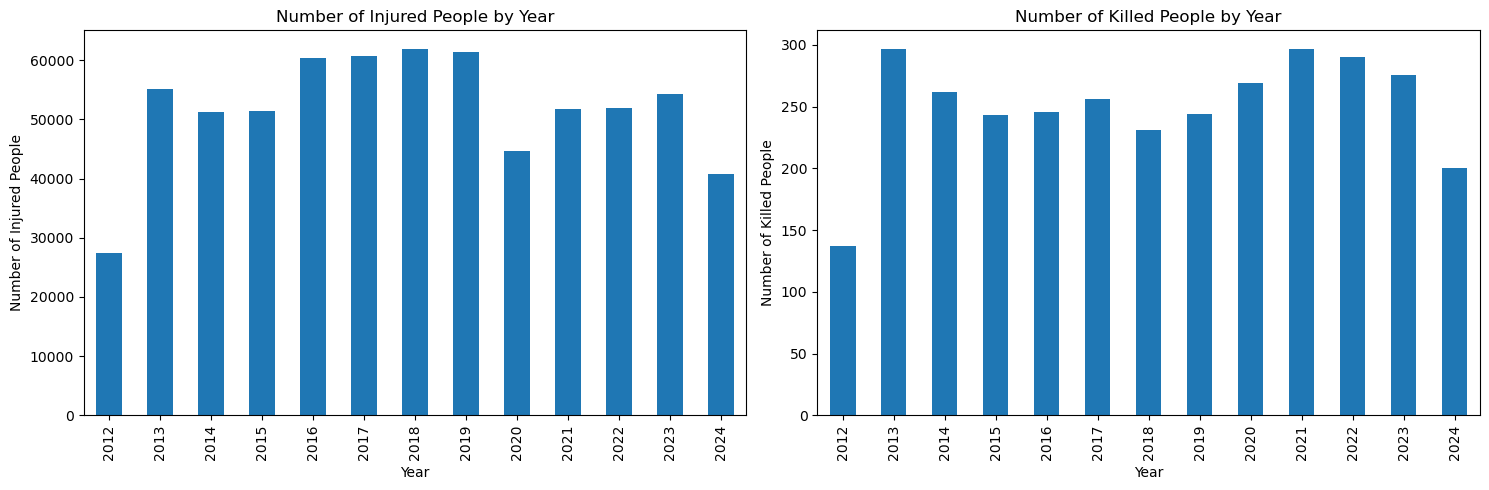

In [65]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Plot Injured
df['Injured'].plot(kind='bar', ax=axes[0], legend=False)
axes[0].set_title('Number of Injured People by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Injured People')

# Plot Killed
df['Killed'].plot(kind='bar', ax=axes[1], legend=False)
axes[1].set_title('Number of Killed People by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Killed People')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

In [66]:
import pandas as pd

# Data for NYC population from 2012 to 2024
data = {
    "Year": list(range(2012, 2025)),
    "Population": [
        8361000,  # 2012
        8399000,  # 2013
        8438000,  # 2014
        8468000,  # 2015
        8491000,  # 2016
        8538000,  # 2017
        8531000,  # 2018
        8337000,  # 2019
        8740000,  # 2020
        8463000,  # 2021
        8412000,  # 2022
        8260000,  # 2023
        8100000   # 2024
    ]
}

# Create DataFrame
nyc_population_df = pd.DataFrame(data)

# Display the DataFrame
nyc_population_df.set_index('Year')

,Population
Year,
2012,8361000
2013,8399000
2014,8438000
2015,8468000
2016,8491000
2017,8538000
2018,8531000
2019,8337000
2020,8740000


In [67]:
# Add the population data to the existing DataFrame
df['Population'] = nyc_population_df.set_index('Year')['Population']

# Display the updated DataFrame
df

,Injured,Killed,Population
Year,,,
2012,27453,137,8361000
2013,55128,297,8399000
2014,51226,262,8438000
2015,51358,243,8468000
2016,60317,246,8491000
2017,60656,256,8538000
2018,61941,231,8531000
2019,61390,244,8337000
2020,44614,269,8740000


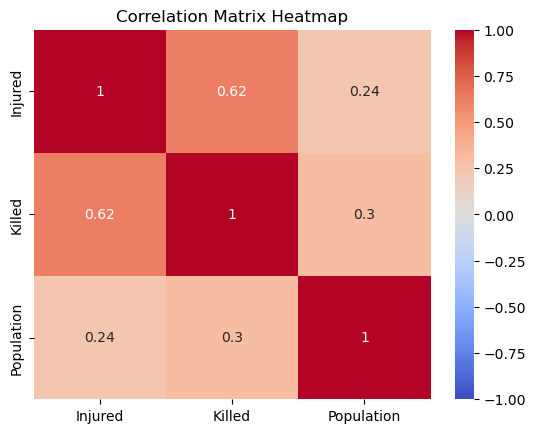

In [68]:
# Generate a heatmap of the correlation matrix of the updated DataFrame, excluding the 'Year' column
import seaborn as sns

# Calculate the correlation matrix
corr = df.corr()

# Generate a heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')

# Display the plot
plt.show()

In [69]:
# Find the variance in the number of injured people by year
injured_variance = df['Injured'].var()

# Find the variance in the number of killed people by year
killed_variance = df['Killed'].var()

# Display the variances
print("Variance in the number of injured people by year: {}".format(injured_variance))
print("Variance in the number of killed people by year: {}".format(killed_variance))

# Find the standard deviation in the number of injured people by year
injured_std = df['Injured'].std()

# Find the standard deviation in the number of killed people by year
killed_std = df['Killed'].std()

# Display the standard deviations
print("Standard deviation in the number of injured people by year: {}".format(injured_std))
print("Standard deviation in the number of killed people by year: {}".format(killed_std))

# Find the coefficient of variation for the number of injured people by year
injured_cv = injured_std / df['Injured'].mean()

# Find the coefficient of variation for the number of killed people by year
killed_cv = killed_std / df['Killed'].mean()

# Display the coefficients of variation
print("Coefficient of variation for the number of injured people by year: {:.2f}".format(injured_cv))
print("Coefficient of variation for the number of killed people by year: {:.2f}".format(killed_cv))

# Find the skewness in the number of injured people by year
injured_skewness = df['Injured'].skew()

# Find the skewness in the number of killed people by year
killed_skewness = df['Killed'].skew()

# Display the skewness values
print("Skewness in the number of injured people by year: {:.2f}".format(injured_skewness))
print("Skewness in the number of killed people by year: {:.2f}".format(killed_skewness))

# Find the kurtosis in the number of injured people by year
injured_kurtosis = df['Injured'].kurtosis()

# Find the kurtosis in the number of killed people by year
killed_kurtosis = df['Killed'].kurtosis()

# Display the kurtosis values
print("Kurtosis in the number of injured people by year: {:.2f}".format(injured_kurtosis))
print("Kurtosis in the number of killed people by year: {:.2f}".format(killed_kurtosis))

# Find the covariance between the number of injured and killed people by year
covariance = df['Injured'].cov(df['Killed'])

# Display the covariance
print("Covariance between the number of injured and killed people by year: {:.2f}".format(covariance))

Variance in the number of injured people by year: 94254610.23076923
Variance in the number of killed people by year: 1913.8076923076922
Standard deviation in the number of injured people by year: 9708.481355534925
Standard deviation in the number of killed people by year: 43.74708781516425
Coefficient of variation for the number of injured people by year: 0.19
Coefficient of variation for the number of killed people by year: 0.18
Skewness in the number of injured people by year: -1.37
Skewness in the number of killed people by year: -1.49
Kurtosis in the number of injured people by year: 2.24
Kurtosis in the number of killed people by year: 2.91
Covariance between the number of injured and killed people by year: 263285.45


In [70]:
# Calculating injury and fatality rates per capita (per 100,000 people for better interpretability)
df['Injury Rate per 100k'] = (df['Injured'] / df['Population']) * 100000
df['Fatality Rate per 100k'] = (df['Killed'] / df['Population']) * 100000

# Displaying the updated DataFrame with the injury and fatality rates
df[['Injured', 'Killed', 'Population', 'Injury Rate per 100k', 'Fatality Rate per 100k']].head()


,Injured,Killed,Population,Injury Rate per 100k,Fatality Rate per 100k
Year,,,,,
2012,27453,137,8361000,328.345892,1.638560
2013,55128,297,8399000,656.363853,3.536135
2014,51226,262,8438000,607.086987,3.105001
2015,51358,243,8468000,606.495040,2.869627
2016,60317,246,8491000,710.363915,2.897185


In [77]:
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import NegativeBinomial
import numpy as np

# Create population projection for 2025-2030 using a linear trend
future_years = np.arange(2025, 2031)
population_trend = np.polyfit(df.index, df['Population'], 1)  # Linear trend
future_population = np.polyval(population_trend, future_years).astype(int)

# Prepare the data for modeling
df['Year'] = df.index  # Add Year as a column for modeling

# Estimate alpha parameter for Negative Binomial distribution
alpha_injured = df['Injured'].var() / df['Injured'].mean()
alpha_killed = df['Killed'].var() / df['Killed'].mean()

# Display the alpha values
print("Estimated alpha for Injured: {:.2f}".format(alpha_injured))
print("Estimated alpha for Killed: {:.2f}".format(alpha_killed))

# Fit Negative Binomial model for Injury Rate
injury_model = GLM(df['Injured'], df[['Year', 'Population']], family=NegativeBinomial(alpha=alpha_injured)).fit()

# Fit Negative Binomial model for Fatality Rate
fatality_model = GLM(df['Killed'], df[['Year', 'Population']], family=NegativeBinomial(alpha=alpha_killed)).fit()

# Create future DataFrame for predictions
future_df = pd.DataFrame({
    'Year': future_years,
    'Population': future_population
})

# Predict the number of injuries and fatalities for 2025-2030 in integers
future_df['Predicted Injured'] = injury_model.predict(future_df[['Year', 'Population']]).astype(int)
future_df['Predicted Killed'] = fatality_model.predict(future_df[['Year', 'Population']]).astype(int)

# Display the prediction results for 2025-2030
future_df[['Year', 'Population', 'Predicted Injured', 'Predicted Killed']].set_index('Year')

Estimated alpha for Injured: 1821.36
Estimated alpha for Killed: 7.66


,Population,Predicted Injured,Predicted Killed
Year,,,
2025,8345884,51671,245
2026,8334439,51670,244
2027,8322994,51669,244
2028,8311549,51668,243
2029,8300104,51667,242
2030,8288659,51667,242
